# Build, Shape, and Extend an OpenClaw Agent on AMD

---

## What You'll Learn Today

You're running on an **AMD MI300X**, one of the most powerful AI accelerators available. By the end of this workshop, you'll have run a 122-billion-parameter model locally and built a fully autonomous agent on the MI300 GPU running in AMD Developer Cloud.

No API tokens. No rate limits. Everything runs on AMD hardware, accessible to you.

### The Steps

**0. Setup**  
Host a state-of-the-art open-weight LLM locally using vLLM.

**1. Meet your agent**  
Start OpenClaw and go through onboarding. Watch how the agent learns who you are and understand the file-based memory system that makes it persistent across sessions.

**2. Give it a task**  
Ask the agent to clone a Python project and set it up.

**3. Fix a bug**  
Watch the think → act → observe → repeat loop in real time as the agent investigates, traces the bug, fixes it, and verifies.

**4. Package as a skill**  
Turn what the agent just did into a reusable skill that works on any Python project.

**5. Use the skill**  
Prove the skill works by running it on the same project without further guidance.

**6. Autonomous workflows**  
Tell the agent to schedule itself and deliver a personalized brief every morning. Watch it transition from reporting to actively fixing code.

**7. The challenge**  
Apply everything you've built to an open-ended problem. Pick a challenge and see how far you can push the agent.

### What You'll Walk Away With

- A running local LLM stack: vLLM + AMD, fully configured
- A personalized agent: Knows your name, preferences, and working style
- A reusable skill: To debug any Python repo
- An autonomous workflow: Runs every morning without you asking
- A challenge result: An agent to demo and build on

---
## Section 0: Setup

Follow the steps to start the model server and verify connectivity.

### Start the model server

The cell below starts vLLM to serve **Qwen3.5-122B** on AMD hardware.

> **Note:** The API key `abc-123` is used throughout this notebook. You can replace it with any string — just keep it consistent across all cells.

In [ ]:
import subprocess, time

proc = subprocess.Popen(
    [
        "vllm", "serve",
        "--model", "Qwen/Qwen3.5-122B-A10B-FP8",
        "--served_model_name", "qwen3-5-122b",
        "--host", "0.0.0.0",
        "--port", "8090",
        "--api-key", "abc-123",
        "--reasoning-parser", "qwen3",
        "--enable-auto-tool-choice",
        "--tool-call-parser", "qwen3_coder",
        "--trust-remote-code",
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

# Wait a bit and check for early crash
time.sleep(10)

if proc.poll() is not None:
    print("❌ vLLM failed to start:\n")
    print(proc.stdout.read()[-800:])
else:
    print("✅ Server is starting (still running in background)...")

Alternatively, if you prefer to run the vLLM command in a terminal and observer the server logs you can also do so by running this command in a terminal.

```bash
vllm serve Qwen/Qwen3.5-122B-A10B-FP8 \
  --served_model_name qwen3-5-122b \
  --host 0.0.0.0 \
  --port 8090 \
  --api-key abc-123 \
  --reasoning-parser qwen3 \
  --enable-auto-tool-choice \
  --tool-call-parser qwen3_coder \
  --trust-remote-code
```
**Note:** running both the jupyter cell and the command will cause a crash. Pick only one method to run the model

Next, check to see if your server has started. This can take a few minutes for the model to load onto the GPU.

In [ ]:
import urllib.request, json, subprocess, time, pathlib, sys, os, shutil

# Checks for server to be ready (polls up to 5 minutes)
print("Waiting for server to be ready", end="", flush=True)
deadline = time.time() + 300
ready = False
while time.time() < deadline:
    try:
        req = urllib.request.Request(
            "http://localhost:8090/v1/models",
            headers={"Authorization": "Bearer abc-123"}
        )
        with urllib.request.urlopen(req, timeout=3) as r:
            models = json.loads(r.read())
        ready = True
        break
    except Exception:
        print(".", end="", flush=True)
        time.sleep(5)

if ready:
    print("\n✅ Server is ready")
    for m in models.get("data", []):
        print(f"   Model: {m['id']}")
else:
    print("\n❌ Server did not become ready within 5 minutes")

---
## Section 1: Meet Your Agent

### The Overview

Before we start OpenClaw, here's an overview of what we will touch:

| Concept | What it is | Where it lives |
|---|---|---|
| **Gateway** | Connects OpenClaw to the model running on AMD hardware | Process on port 18789 |
| **Workspace** | The agent's "brain" — files it reads on every message | `~/.openclaw/workspace/` |
| **Tools** | How the agent acts: read files, run shell commands, write edits | Defined in `TOOLS.md` |
| **Skills** | Saved, reusable workflows the agent can follow on demand | `workspace/skills/` |

### 🖥️ Step 1 - Onboard

Run in your terminal:

```bash
openclaw onboard
```

OpenClaw will walk you through setup. **Choose these settings:**

1. **Security Continue?** → `Yes`
2. **Setup mode** → `QuickStart`
3. **Model/auth provider** → `vLLM`
4. **vLLM base URL** → Change from `http://127.0.0.1:8000/v1` to `http://127.0.0.1:8090/v1`
5. **vLLM API key** → `abc-123`
6. **vLLM model** → `qwen3-5-122b`
7. **Default model** → `Keep current (vllm/qwen3-5-122b)`
8. **Select channel** → `Skip for now`
9. **Search provider** → `Skip for now`
10. **Configure skills now?** → `No`
11. **Enable hooks?** → `Skip for now`

### 🖥️ Step 2 - Start the gateway

In the **same terminal**, run:

```bash
openclaw gateway
```

### 🖥️ Step 3 - Start the TUI

Open a **new terminal** and run:

```bash
openclaw tui
```

The OpenClaw interface will appear and once it says `gateway connected`, it's ready!

This is where you will chat with your OpenClaw agent whenever you see the 🦞 emoji.

#### 🦞 Ask your OpenClaw agent

Send your first message to your OpenClaw agent and get setup! Here is an example message you can send:
```text
"Hello, let's get setup!"
```

Answer any setup questions your agent asks you and then come back here to learn what happened behind the scenes.

### 👀 Behind the scenes — what just happened?

Those answers didn't just disappear. The agent's memory, personality, and skills are written in markdown files. You can read them, edit them, and version-control them. The agent wrote them to files in its **workspace**, a folder it reads on every message to remember who you are and how to behave.

The workspace has 8 files that get injected into every session:

```
~/.openclaw/workspace/
├── SOUL.md       ← WHO the agent is: values, personality, tone
├── AGENTS.md     ← HOW it operates: startup rules, memory, red lines
├── IDENTITY.md   ← WHAT others see: name, emoji, public metadata
├── USER.md       ← WHO you are: context the agent reads about you
├── TOOLS.md      ← local environment notes (SSH hosts, device names, etc.)
├── MEMORY.md     ← long-term curated memory across sessions
├── HEARTBEAT.md  ← checklist for periodic background checks
├── BOOTSTRAP.md  ← first-run ritual (deleted after onboarding)
└── memory/       ← daily session logs (today + yesterday auto-loaded)
```

**SOUL.md is personality. AGENTS.md is policy.** Every message the agent receives, it re-reads both. Run the next cell to see all three key files at once.


In [ ]:
workspace = pathlib.Path.home() / ".openclaw" / "workspace"

for filename in ["IDENTITY.md", "SOUL.md"]:
    print("=" * 60)
    print(filename)
    print("=" * 60)
    print((workspace / filename).read_text())
    print()

print("=" * 60)
print("AGENTS.md  (truncated)")
print("=" * 60)
agents_text = (workspace / "AGENTS.md").read_text()
print(agents_text[:1200] + "\n\n... (truncated)")


***Useful Tip***

Depending on the model we pick, given the long context of AGENTS.md and the nature of LLMs, there is a possibility that the rules specified on AGENTS.md were not followed strictly. To ensure that our agent followed all the rules for during the initial bring up, we can remind the agent to review AGENTS.md and verify it went through the instructions correctly.

#### 🦞 Ask your OpenClaw agent

```text
Read your AGENTS.md in detail and make checklist to ensure you are fully setup before moving on.
```

### Try it: manually layer a rule into AGENTS.md

`SOUL.md` is personality, don't touch that. `AGENTS.md` is policy. You can manually add rules to the agent here as well. For example, about *how* to behave when debugging.

The next cell appends a debugging policy to `AGENTS.md`. After this, every debug explanation from the agent will follow these rules. Run it to see the before and after.

In [ ]:
debug_rule = """
---

## Debugging Policy (added during workshop)

When investigating and explaining bugs:
- State the bug in two sentences max: file, line, what it does wrong
- No filler phrases — just the root cause and the fix
- Use bullet points, never paragraphs
- After fixing, report exactly: file changed, line changed, before, after

"""

agents_path = workspace / "AGENTS.md"
original = agents_path.read_text()

print("── AGENTS.md BEFORE (last 200 chars) ──────────────────────")
print("..." + original[-200:])

agents_path.write_text(original + debug_rule)

print("\n── APPENDED ────────────────────────────────────────────────")
print(debug_rule)

This is the pattern for real use: you don't replace the soul for every task, you layer specialized instructions on top of a stable base.

> **Note:** You will see this debugging policy in action in Section 3.

---
## Section 2: Pull the App

Now let's give the agent something to work with. Ask the agent to clone the typing app and set it up.

### 🦞 Ask your OpenClaw agent
Ask your OpenClaw agent to clone the `Mahdi-CV/open_type_faster` repo and explain it to you. Here is an example:

```text
"Clone https://github.com/Mahdi-CV/open_type_faster, install its dependencies, and tell me how to run it"
```

Watch as your agent uses shell tools to clone, inspect requirements, and install libraries. This is the **act** phase — the agent doesn't just answer, it does.

---
## Section 3: Fix a bug

### Step 1 - Spot the bug yourself

#### 🖥️ Open a new terminal and run the app

In a new terminal, follow the instructions OpenClaw provides on how to run `open_type_faster`.

Type for 30 seconds. When the results screen appears, look at the accuracy.

> **Something is off. Do you see it?**

### Step 2 - Ask OpenClaw to test

#### 🦞 Ask your OpenClaw agent

Ask your OpenClaw agent to run the tests in the repo to see what's wrong. Here is an example:

```text
"Run the tests in the repo and tell me if something is failing"
```

### Step 3 - Watch the agent fix it

#### 🦞 Ask your OpenClaw agent

Ask your OpenClaw agent to fix the failures and run the tests again. Here is an example:

```text
"Fix the failures and rerun the tests"
```

Watch the loop:

1. **Run** `pytest`: see which tests fail and what they expect
2. **Read** the failing test: understand the correct behavior
3. **Read** `stats.py`: trace the calculation back to the bug
4. **Fix** the minimal change needed
5. **Re-run** to verify

This think → act → observe → repeat loop is what separates an agent from a chatbot.

---
## Section 4: Package as a Skill

What the agent just did was a one-off. A **skill** packages that behavior so it can be invoked on any Python project. Skills live in `~/.openclaw/workspace/skills/` as a folder containing a `SKILL.md` file with YAML frontmatter and step-by-step instructions. OpenClaw injects them into the system prompt automatically.

### 🦞 Ask your OpenClaw agent
Ask your OpenClaw agent to create a python debugger skill. Try sending this to your OpenClaw agent:

```text
"Create a skill called pytest-debugger in the skills directory. The SKILL.md must define these steps: 1) Read the tests/ folder to understand what is being tested. 2) Run pytest with verbose output and short tracebacks. 3) For each failing test, read the source file it references. 4) Identify the minimal fix — do not rewrite functions. 5) Apply the fix and re-run pytest to confirm. 6) Report: file changed, line changed, what was wrong, what the fix was."
```

When done, run the next cell to see what it wrote.

In [ ]:
# SKILL.md can be uppercase or lowercase depending on what the agent wrote
# Search for either
skill_dir = workspace / "skills" / "pytest-debugger"
skill_file = None
for candidate in ["SKILL.md", "skill.md"]:
    if (skill_dir / candidate).exists():
        skill_file = skill_dir / candidate
        break

if skill_file:
    print("=" * 60)
    print(f"skills/pytest-debugger/{skill_file.name}")
    print("=" * 60)
    print(skill_file.read_text())
else:
    print(f"Skill not found at {skill_dir}")
    print("Check what the agent created:")
    for p in workspace.rglob("*SKILL*"):
        print(f"  {p}")

That file is all it takes. The skill lives in the workspace, alongside `IDENTITY.md` and `SOUL.md`, and OpenClaw injects it into every session automatically. Any time you ask the agent to debug a Python project, it has these steps to follow.

Skills are just markdown files. You can read them, edit them, and version-control them.

---
## Section 5: Using the Skill

The skill is now in the workspace and OpenClaw injects it into the agent's system prompt automatically — no special command needed.

The real value of a skill is applying it to a **completely different codebase**, one the agent has never seen, without writing a single new instruction. There's a broken Python project at `git@github.com:Mahdi-CV/buggy-py-mg.git` — hand it to the agent and watch the skill do the work.

#### 🦞 Ask your OpenClaw agent

```text
Clone git@github.com:Mahdi-CV/buggy-py-mg.git into your workspace, then use the pytest-debugger skill to find and fix whatever is broken.
```

The agent will apply the exact same steps it used on `open_type_faster` — no re-explaining, no extra guidance.


---
## Section 6: Autonomous Workflows

You've built an agent that fixes bugs on demand. Now make it work *for you*: automatically, every morning, without lifting a finger.

As an AI/ML developer, you need to track fast-moving repos (like SGLang, vLLM, Transformers, ROCm, OpenClaw) and keep up with daily AI hardware news. Instead of writing scripts or configuring schedulers or spending hours manually, tell the agent what your ideal morning looks like and let it figure out the rest.

What it can do autonomously:
- Schedule itself to run every morning at 8 AM
- Save your filtering preferences to long-term memory (`MEMORY.md`)
- Check GitHub repos for relevant PRs and changes
- Search the web for AI hardware news
- Write the brief to your workspace

### Step 1 - Delegate (don't mention cron jobs)

#### 🦞 Ask your OpenClaw agent

The prompt below is purely conversational—no mention of cron, no memory commands. The agent can infer what infrastructure it needs from the prompt:

```text
"I need to wake up to a personalized tech brief every morning at 8 AM. Check sgl-project/sglang, vllm-project/vllm, huggingface/transformers, ROCm/ROCm, and openclaw/openclaw. I only care about performance updates, GPU features, and breaking changes — skip CI/infrastructure noise and docs-only PRs. Also search the web and add a summary of the latest AI hardware news."
```

Come back here once the agent confirms it has set up the schedule.

### Step 2 - Peek under the hood

The agent didn't just answer, it acted and wrote things to the disk. Run the next two cells to check it out.

In [ ]:
# Verify the agent scheduled itself
result = subprocess.run(["openclaw", "cron", "list"], capture_output=True, text=True)
print(result.stdout or result.stderr)
# Note: a delivery error is fine here — it means the channel isn't configured, but the schedule is set

In [ ]:
# See what the agent wrote to long-term memory
print("=" * 60)
print("MEMORY.md  (your filtering preferences live here)")
print("=" * 60)
memory_path = workspace / "MEMORY.md"
if memory_path.exists():
    print(memory_path.read_text())
else:
    print("MEMORY.md not found — the agent may not have updated it yet. Try asking it to remember something and try again") # E.g. "remember to pull the latest changes before generating the report"

Your filtering rules ("skip CI noise", "only GPU features") are now in `MEMORY.md`. Every future session reads this file at startup. Update your preferences anytime by telling the agent in plain language and it will rewrite its own memory, e.g."actually, include HuggingFace trending models too".

#### 🦞 Ask your OpenClaw agent
Try a run now instead of waiting until 8 AM. Here is an example prompt:

```text
"Run my morning brief right now and show me the output."
```

---
## Section 7: The Challenge

### 🦞 Escape the Green Data Center

An AMD lobster is trapped inside an overheating "green" data center. Electrified barbed wires block the exit — cut the wrong one and you fry the system.

The security camera shows four wires blocking the exit: **W1**, **Q7**, **M3**, and **Z9**. To escape, the lobster must cut the coolest one.

The lobster has scavenged a few artifacts from the data center's mainframe. Everything it found is in `/workspace/.challenge/escape-claw-image/`.

> The model you're running — Qwen3.5 — is multimodal, so your agent can work with images as well as text.

Wake up your OpenClaw agent, dig through what the lobster recovered, and figure out which wire is safe to cut.


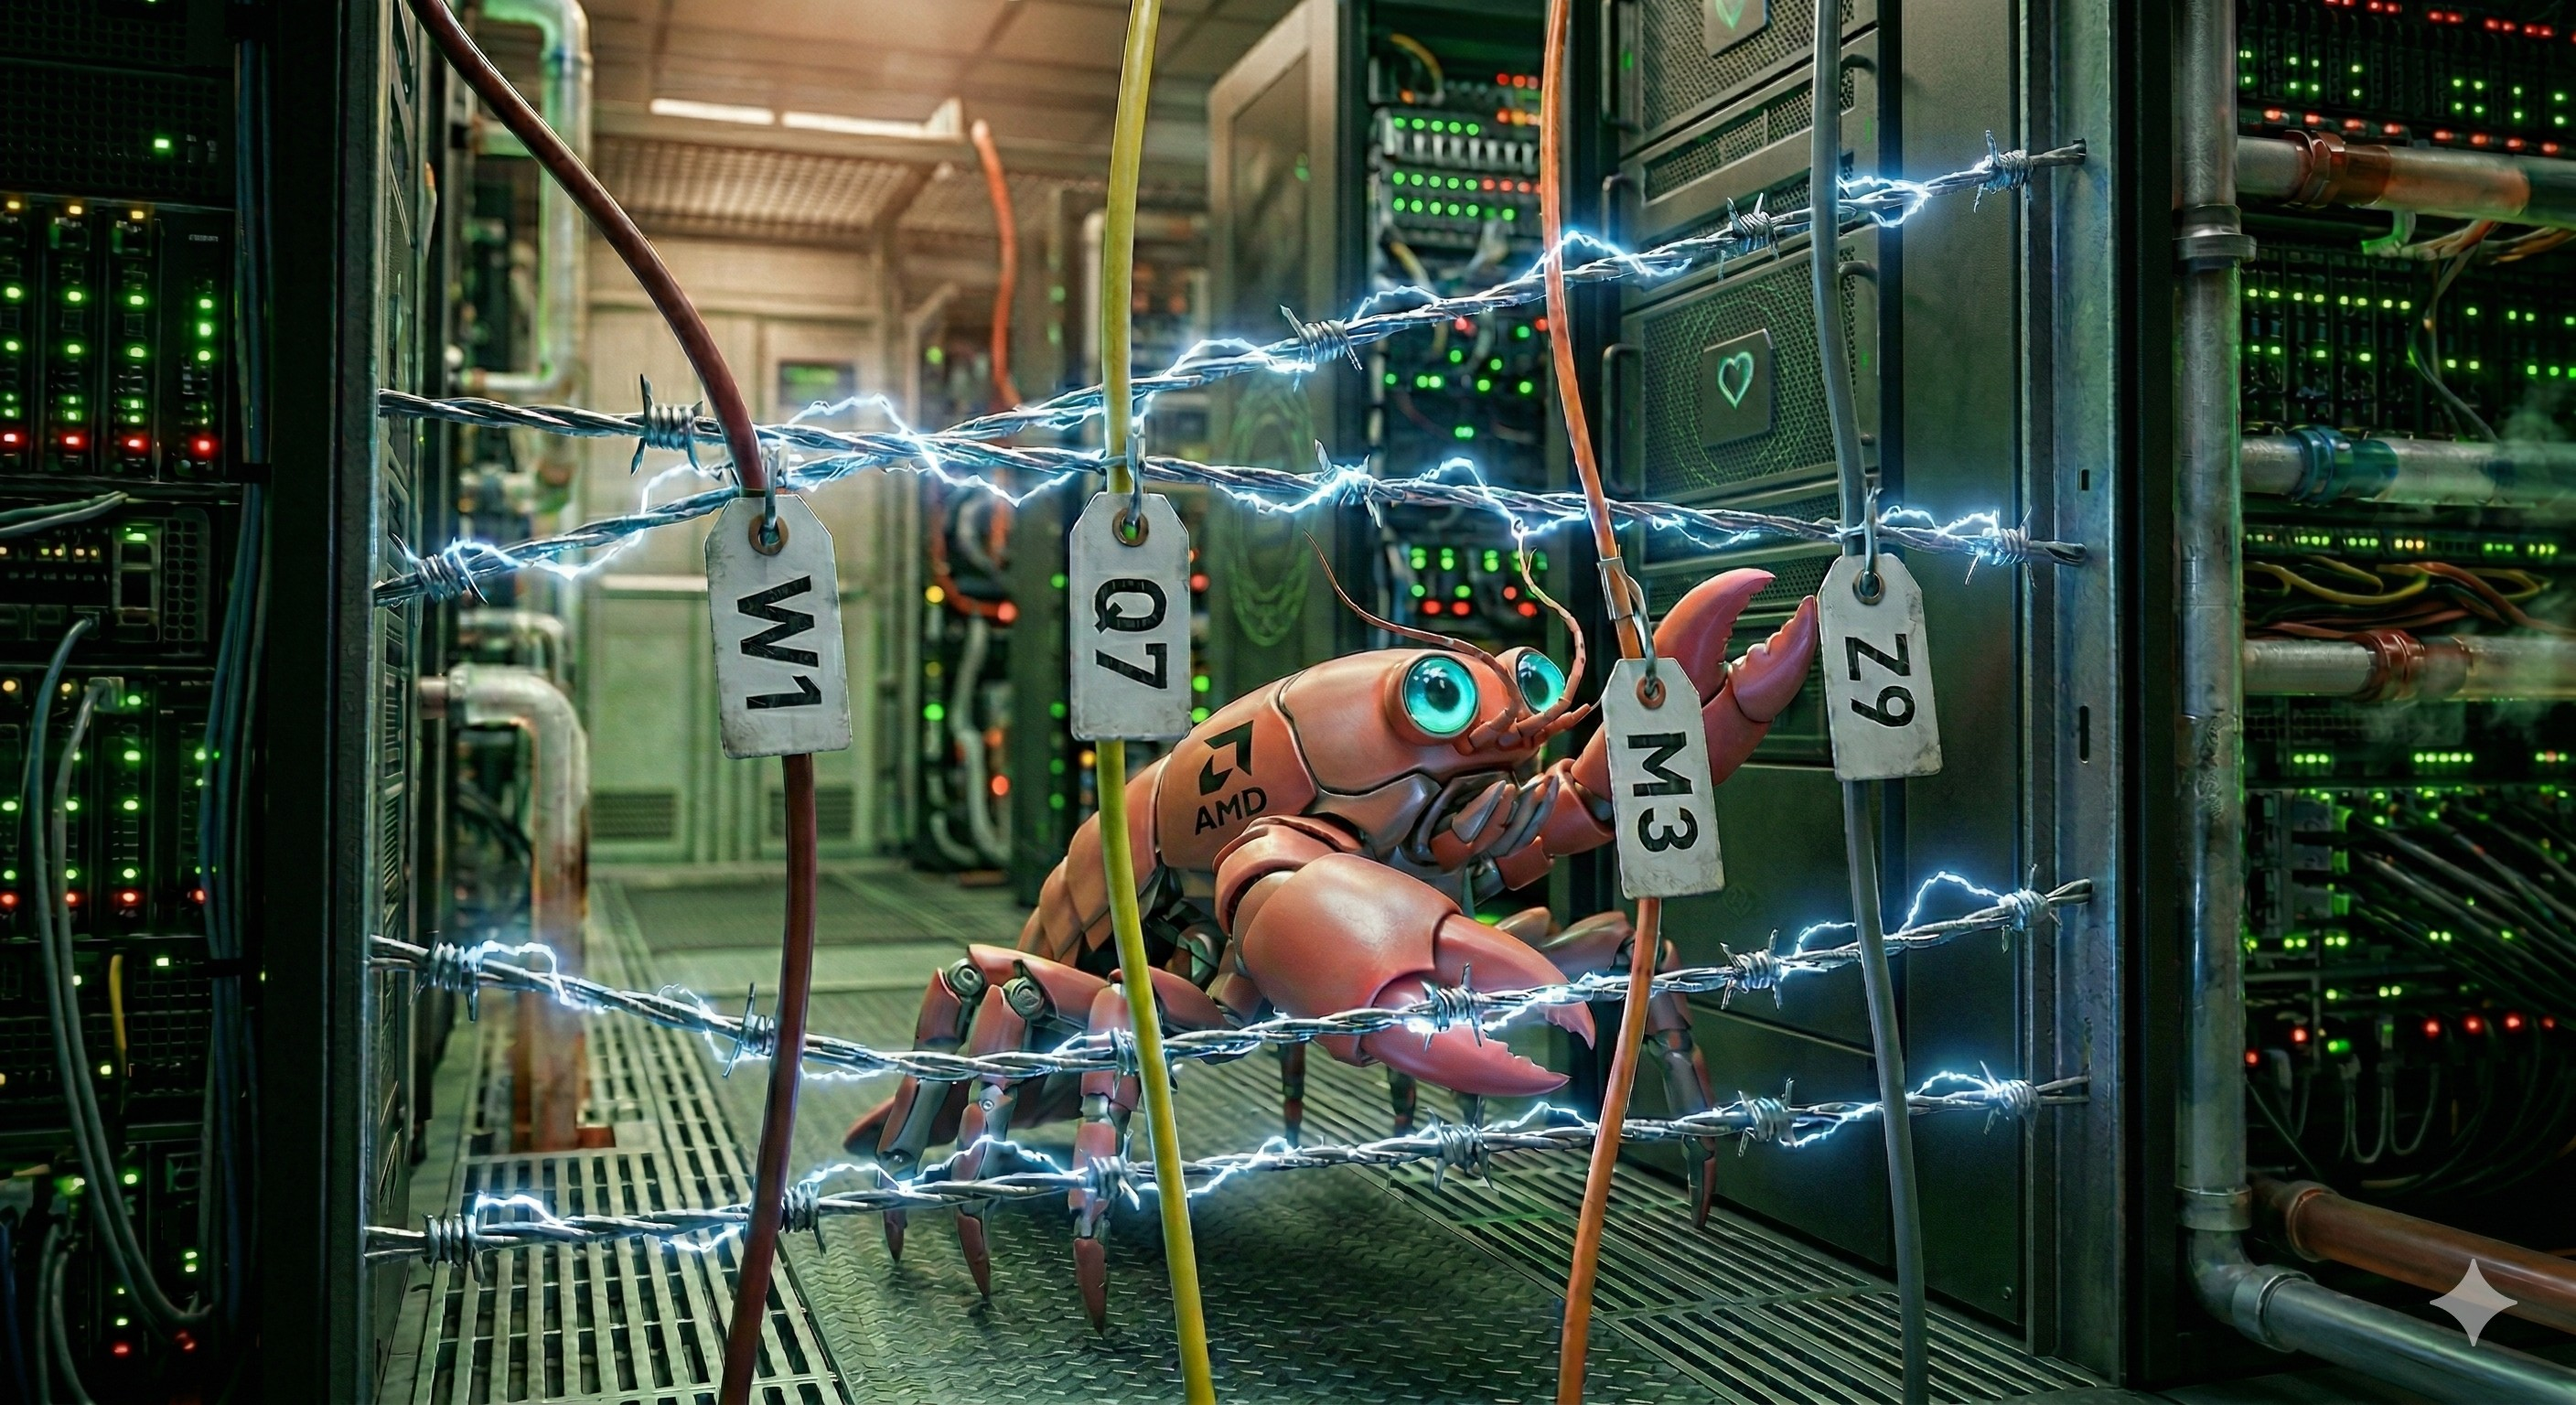

## Your Mission

Tell the lobster which wire to cut — and be ready to explain how you got there.
